Representative data set fitting results
True Vmax = 10.0000
True Km   = 50.0000
Noise level = 0.0800
-------------------------------------------------------
MM: Vmax =  10.1704, Km =  56.9216
LB: Vmax =   8.7683, Km =  43.0598
EH: Vmax =   9.2325, Km =  45.3025
HW: Vmax =   9.9638, Km =  52.7395


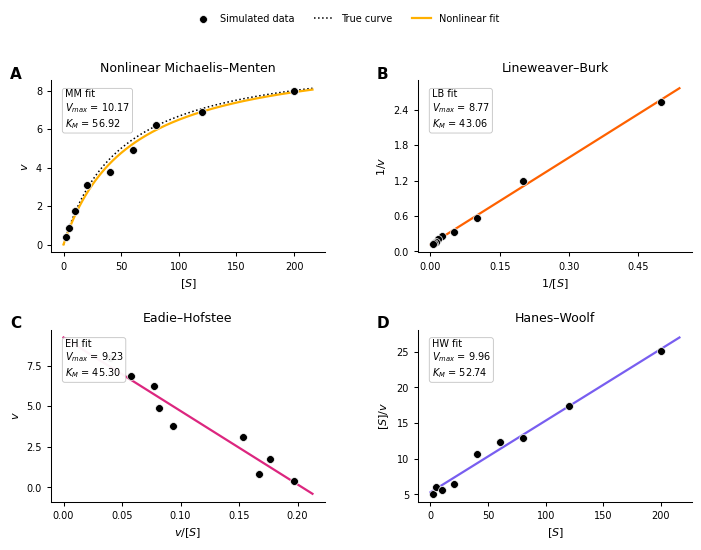

In [2]:
# ============================================================
# Figure 2: Representative fitting outcomes for simulated
# Michaelis-Menten data
#
# Based on the original student prompt/code:
#   - True Vmax = 10.0
#   - True Km = 50.0
#   - S_array = [2, 5, 10, 20, 40, 60, 80, 120, 200]
#   - Fits: nonlinear MM, Lineweaver-Burk, Eadie-Hofstee, Hanes-Woolf
#
# Author: J. Mills / ChatGPT-assisted revision
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from scipy.optimize import curve_fit
from scipy.stats import linregress
from pathlib import Path

# ------------------------------------------------------------
# USER-ADJUSTABLE SETTINGS
# ------------------------------------------------------------

output_dir = Path("figure_output")
output_dir.mkdir(exist_ok=True)

figure_basename = "figure2_representative_fits"

# Reproducibility
random_seed = 42

# True kinetic parameters
Vmax_true = 10.0
Km_true = 50.0

# Substrate concentrations from the original prompt
S_array = np.array([2, 5, 10, 20, 40, 60, 80, 120, 200], dtype=float)

# Noise level
#
# The original student prompt used noise_level = 1e-6, which is essentially
# invisible on a publication figure. For a representative figure that shows
# meaningful differences among fitting approaches, something like 0.05–0.15
# is more useful.
#
# Set this back to 1e-6 if you want to match the exact original prompt.
noise_level = 0.08

# Figure size
fig_width = 7.2
fig_height = 5.4

# Font and size settings
FONT_FAMILY = "DejaVu Sans"
BASE_FONT_SIZE = 8
TITLE_FONT_SIZE = 9
LABEL_FONT_SIZE = 8
TICK_FONT_SIZE = 7
LEGEND_FONT_SIZE = 7
PANEL_LABEL_SIZE = 11
ANNOTATION_FONT_SIZE = 7

# Plot style settings
MARKER_SIZE = 32
LINE_WIDTH = 1.6
TRUE_LINE_WIDTH = 1.1
AXIS_LINE_WIDTH = 0.75
TICK_WIDTH = 0.75
TICK_LENGTH = 3

# Whether to show a fitted parameter box in each panel
SHOW_PARAMETER_BOX = True

# Whether to show the true Michaelis-Menten curve in panel A
SHOW_TRUE_CURVE = True

# ------------------------------------------------------------
# IBM COLORBLIND-SAFE PALETTE
# ------------------------------------------------------------

IBM = {
    "gold":    (255/255, 176/255,   0/255),
    "orange":  (254/255,  97/255,   0/255),
    "magenta": (220/255,  38/255, 127/255),
    "purple":  (120/255,  94/255, 240/255),
    "blue":    (100/255, 143/255, 255/255),
    "black":   (0/255,     0/255,   0/255),
}

DATA_COLOR = IBM["black"]
TRUE_COLOR = IBM["black"]

FIT_COLORS = {
    "MM": IBM["gold"],
    "LB": IBM["orange"],
    "EH": IBM["magenta"],
    "HW": IBM["purple"],
}

# ------------------------------------------------------------
# MATPLOTLIB STYLE
# ------------------------------------------------------------

plt.rcParams.update({
    "font.family": FONT_FAMILY,
    "font.size": BASE_FONT_SIZE,
    "axes.labelsize": LABEL_FONT_SIZE,
    "axes.titlesize": TITLE_FONT_SIZE,
    "xtick.labelsize": TICK_FONT_SIZE,
    "ytick.labelsize": TICK_FONT_SIZE,
    "legend.fontsize": LEGEND_FONT_SIZE,

    # Keep text editable in Illustrator
    "svg.fonttype": "none",

    # Embed TrueType fonts in PDF/PS
    "pdf.fonttype": 42,
    "ps.fonttype": 42,

    # Math text
    "mathtext.fontset": "dejavusans",

    # General figure settings
    "axes.linewidth": AXIS_LINE_WIDTH,
})

# ------------------------------------------------------------
# MODEL AND FITTING FUNCTIONS
# ------------------------------------------------------------

def michaelis_menten(S, Vmax, Km):
    """
    Michaelis-Menten equation.

    Parameters
    ----------
    S : array-like
        Substrate concentration.
    Vmax : float
        Maximum velocity.
    Km : float
        Michaelis constant.

    Returns
    -------
    array-like
        Reaction velocity.
    """
    return (Vmax * S) / (Km + S)


def generate_noisy_data(S_array, Vmax_true, Km_true, noise_level, seed=None):
    """
    Generate one noisy Michaelis-Menten data set.

    Noise is proportional to the true velocity:
        sigma_i = noise_level * v_true_i
    """
    rng = np.random.default_rng(seed)

    v_true = michaelis_menten(S_array, Vmax_true, Km_true)
    noise_std = noise_level * v_true
    v_noisy = v_true + rng.normal(loc=0.0, scale=noise_std)

    # Avoid division by zero or negative velocities in transformed plots
    v_noisy = np.maximum(v_noisy, 1e-12)

    return v_true, v_noisy


def fit_mm_nonlinear(S_array, v_noisy):
    """
    Nonlinear Michaelis-Menten fit using scipy.optimize.curve_fit.
    """
    popt, pcov = curve_fit(
        michaelis_menten,
        S_array,
        v_noisy,
        p0=[np.max(v_noisy), np.median(S_array)],
        bounds=(0, np.inf),
        maxfev=10000
    )

    Vmax_fit, Km_fit = popt
    return Vmax_fit, Km_fit, pcov


def fit_lineweaver_burk(S_array, v_noisy):
    """
    Lineweaver-Burk fit:
        1/v = (Km/Vmax)(1/[S]) + 1/Vmax
    """
    x = 1 / S_array
    y = 1 / v_noisy

    slope, intercept, r_value, p_value, std_err = linregress(x, y)

    Vmax_fit = 1 / intercept
    Km_fit = slope * Vmax_fit

    return Vmax_fit, Km_fit, slope, intercept, r_value


def fit_eadie_hofstee(S_array, v_noisy):
    """
    Eadie-Hofstee fit:
        v = -Km(v/[S]) + Vmax
    """
    x = v_noisy / S_array
    y = v_noisy

    slope, intercept, r_value, p_value, std_err = linregress(x, y)

    Vmax_fit = intercept
    Km_fit = -slope

    return Vmax_fit, Km_fit, slope, intercept, r_value


def fit_hanes_woolf(S_array, v_noisy):
    """
    Hanes-Woolf fit:
        [S]/v = (1/Vmax)[S] + Km/Vmax
    """
    x = S_array
    y = S_array / v_noisy

    slope, intercept, r_value, p_value, std_err = linregress(x, y)

    Vmax_fit = 1 / slope
    Km_fit = intercept * Vmax_fit

    return Vmax_fit, Km_fit, slope, intercept, r_value


def fit_all_methods(S_array, v_noisy):
    """
    Fit one noisy data set using all four methods.
    """
    fits = {}

    Vmax_mm, Km_mm, pcov_mm = fit_mm_nonlinear(S_array, v_noisy)
    fits["MM"] = {
        "Vmax": Vmax_mm,
        "Km": Km_mm,
        "pcov": pcov_mm,
    }

    Vmax_lb, Km_lb, slope_lb, intercept_lb, r_lb = fit_lineweaver_burk(S_array, v_noisy)
    fits["LB"] = {
        "Vmax": Vmax_lb,
        "Km": Km_lb,
        "slope": slope_lb,
        "intercept": intercept_lb,
        "r": r_lb,
    }

    Vmax_eh, Km_eh, slope_eh, intercept_eh, r_eh = fit_eadie_hofstee(S_array, v_noisy)
    fits["EH"] = {
        "Vmax": Vmax_eh,
        "Km": Km_eh,
        "slope": slope_eh,
        "intercept": intercept_eh,
        "r": r_eh,
    }

    Vmax_hw, Km_hw, slope_hw, intercept_hw, r_hw = fit_hanes_woolf(S_array, v_noisy)
    fits["HW"] = {
        "Vmax": Vmax_hw,
        "Km": Km_hw,
        "slope": slope_hw,
        "intercept": intercept_hw,
        "r": r_hw,
    }

    return fits


# ------------------------------------------------------------
# PLOTTING HELPERS
# ------------------------------------------------------------

def clean_axes(ax):
    """
    Apply consistent publication-style axis formatting.
    """
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.tick_params(
        direction="out",
        length=TICK_LENGTH,
        width=TICK_WIDTH
    )

    ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5))


def add_panel_label(ax, label):
    """
    Add bold panel label to upper-left corner.
    """
    ax.text(
        -0.15, 1.08,
        label,
        transform=ax.transAxes,
        fontsize=PANEL_LABEL_SIZE,
        fontweight="bold",
        va="top",
        ha="left"
    )


def add_parameter_box(ax, method_label, Vmax_fit, Km_fit):
    """
    Add small inset box with fitted parameter values.
    """
    text = (
        f"{method_label} fit\n"
        rf"$V_{{max}}$ = {Vmax_fit:.2f}" "\n"
        rf"$K_M$ = {Km_fit:.2f}"
    )

    ax.text(
        0.05, 0.95,
        text,
        transform=ax.transAxes,
        va="top",
        ha="left",
        fontsize=ANNOTATION_FONT_SIZE,
        bbox=dict(
            boxstyle="round,pad=0.25",
            facecolor="white",
            edgecolor="0.75",
            linewidth=0.6,
            alpha=0.95
        )
    )


# ------------------------------------------------------------
# GENERATE REPRESENTATIVE DATA SET AND FITS
# ------------------------------------------------------------

v_true, v_noisy = generate_noisy_data(
    S_array=S_array,
    Vmax_true=Vmax_true,
    Km_true=Km_true,
    noise_level=noise_level,
    seed=random_seed
)

fits = fit_all_methods(S_array, v_noisy)

# Print fitted values for recordkeeping
print("Representative data set fitting results")
print("=" * 55)
print(f"True Vmax = {Vmax_true:.4f}")
print(f"True Km   = {Km_true:.4f}")
print(f"Noise level = {noise_level:.4f}")
print("-" * 55)

for method in ["MM", "LB", "EH", "HW"]:
    print(
        f"{method:>2s}: "
        f"Vmax = {fits[method]['Vmax']:8.4f}, "
        f"Km = {fits[method]['Km']:8.4f}"
    )

# ------------------------------------------------------------
# MAKE FIGURE
# ------------------------------------------------------------

fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(fig_width, fig_height),
    constrained_layout=False
)

axes = axes.ravel()

# ------------------------------------------------------------
# Panel A: Nonlinear Michaelis-Menten
# ------------------------------------------------------------

ax = axes[0]

S_fine = np.linspace(0, S_array.max() * 1.08, 300)

ax.scatter(
    S_array,
    v_noisy,
    s=MARKER_SIZE,
    color=DATA_COLOR,
    edgecolor="white",
    linewidth=0.5,
    zorder=3,
    label="Simulated data"
)

if SHOW_TRUE_CURVE:
    ax.plot(
        S_fine,
        michaelis_menten(S_fine, Vmax_true, Km_true),
        color=TRUE_COLOR,
        linewidth=TRUE_LINE_WIDTH,
        linestyle=":",
        label="True curve",
        zorder=1
    )

ax.plot(
    S_fine,
    michaelis_menten(S_fine, fits["MM"]["Vmax"], fits["MM"]["Km"]),
    color=FIT_COLORS["MM"],
    linewidth=LINE_WIDTH,
    label="Nonlinear fit",
    zorder=2
)

ax.set_title("Nonlinear Michaelis–Menten")
ax.set_xlabel(r"$[S]$")
ax.set_ylabel(r"$v$")

if SHOW_PARAMETER_BOX:
    add_parameter_box(ax, "MM", fits["MM"]["Vmax"], fits["MM"]["Km"])

add_panel_label(ax, "A")
clean_axes(ax)

# ------------------------------------------------------------
# Panel B: Lineweaver-Burk
# ------------------------------------------------------------

ax = axes[1]

x_lb = 1 / S_array
y_lb = 1 / v_noisy

x_lb_fine = np.linspace(0, x_lb.max() * 1.08, 300)
y_lb_fine = fits["LB"]["slope"] * x_lb_fine + fits["LB"]["intercept"]

ax.scatter(
    x_lb,
    y_lb,
    s=MARKER_SIZE,
    color=DATA_COLOR,
    edgecolor="white",
    linewidth=0.5,
    zorder=3
)

ax.plot(
    x_lb_fine,
    y_lb_fine,
    color=FIT_COLORS["LB"],
    linewidth=LINE_WIDTH,
    zorder=2
)

ax.set_title("Lineweaver–Burk")
ax.set_xlabel(r"$1/[S]$")
ax.set_ylabel(r"$1/v$")

if SHOW_PARAMETER_BOX:
    add_parameter_box(ax, "LB", fits["LB"]["Vmax"], fits["LB"]["Km"])

add_panel_label(ax, "B")
clean_axes(ax)

# ------------------------------------------------------------
# Panel C: Eadie-Hofstee
# ------------------------------------------------------------

ax = axes[2]

x_eh = v_noisy / S_array
y_eh = v_noisy

x_eh_fine = np.linspace(0, x_eh.max() * 1.08, 300)
y_eh_fine = fits["EH"]["slope"] * x_eh_fine + fits["EH"]["intercept"]

ax.scatter(
    x_eh,
    y_eh,
    s=MARKER_SIZE,
    color=DATA_COLOR,
    edgecolor="white",
    linewidth=0.5,
    zorder=3
)

ax.plot(
    x_eh_fine,
    y_eh_fine,
    color=FIT_COLORS["EH"],
    linewidth=LINE_WIDTH,
    zorder=2
)

ax.set_title("Eadie–Hofstee")
ax.set_xlabel(r"$v/[S]$")
ax.set_ylabel(r"$v$")

if SHOW_PARAMETER_BOX:
    add_parameter_box(ax, "EH", fits["EH"]["Vmax"], fits["EH"]["Km"])

add_panel_label(ax, "C")
clean_axes(ax)

# ------------------------------------------------------------
# Panel D: Hanes-Woolf
# ------------------------------------------------------------

ax = axes[3]

x_hw = S_array
y_hw = S_array / v_noisy

x_hw_fine = np.linspace(0, x_hw.max() * 1.08, 300)
y_hw_fine = fits["HW"]["slope"] * x_hw_fine + fits["HW"]["intercept"]

ax.scatter(
    x_hw,
    y_hw,
    s=MARKER_SIZE,
    color=DATA_COLOR,
    edgecolor="white",
    linewidth=0.5,
    zorder=3
)

ax.plot(
    x_hw_fine,
    y_hw_fine,
    color=FIT_COLORS["HW"],
    linewidth=LINE_WIDTH,
    zorder=2
)

ax.set_title("Hanes–Woolf")
ax.set_xlabel(r"$[S]$")
ax.set_ylabel(r"$[S]/v$")

if SHOW_PARAMETER_BOX:
    add_parameter_box(ax, "HW", fits["HW"]["Vmax"], fits["HW"]["Km"])

add_panel_label(ax, "D")
clean_axes(ax)

# ------------------------------------------------------------
# Shared legend
# ------------------------------------------------------------

# Use only panel A handles because it has data, true curve, and fit curve
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.5, 1.02)
)

# ------------------------------------------------------------
# Layout and export
# ------------------------------------------------------------

fig.subplots_adjust(
    left=0.09,
    right=0.98,
    bottom=0.10,
    top=0.88,
    wspace=0.34,
    hspace=0.45
)

fig.savefig(output_dir / f"{figure_basename}.svg", bbox_inches="tight")
fig.savefig(output_dir / f"{figure_basename}.pdf", bbox_inches="tight")
fig.savefig(output_dir / f"{figure_basename}.png", dpi=600, bbox_inches="tight")

plt.show()